In [19]:
#SET UP
!pip install ultralytics
import os

# For files
print(os.path.abspath("best.pt"))
from ultralytics import YOLO
import torch
import numpy as np
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import requests
from io import BytesIO
from torchvision.models import efficientnet_b0

/content/best.pt


In [20]:

detector = YOLO("/content/FoodModel/best.pt")  # Update with your YOLO model path

IMG_PATH = "https://s7d1.scene7.com/is/image/mcdonalds/DC_202307_8950_EVM_M_2Cheeseburger_Coke_Glass_1564x1564-1:product-header-mobile?wid=500&hei=500&dpr=off"

class FoodClassifier(nn.Module):
    def __init__(self, num_classes=101):
        super().__init__()
        base_model = efficientnet_b0(pretrained=True)

        self.features = base_model.features
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.2, inplace=True),
            nn.Linear(base_model.classifier[1].in_features, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        # Apply adaptive average pooling to reduce spatial dimensions to 1x1
        x = nn.functional.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        return self.classifier(x)

food_classifier = FoodClassifier(num_classes=101)

food_classifier.load_state_dict(
    torch.load('/content/FoodModel/food_classifier.pth', map_location='cpu')
)
food_classifier.eval()

food_classes = [
    "apple_pie",
    "baby_back_ribs",
    "baklava",
    "beef_carpaccio",
    "beef_tartare",
    "beet_salad",
    "beignets",
    "bibimbap",
    "bread_pudding",
    "breakfast_burrito",
    "bruschetta",
    "caesar_salad",
    "cannoli",
    "caprese_salad",
    "carrot_cake",
    "ceviche",
    "cheesecake",
    "cheese_plate",
    "chicken_curry",
    "chicken_quesadilla",
    "chicken_wings",
    "chocolate_cake",
    "chocolate_mousse",
    "churros",
    "clam_chowder",
    "club_sandwich",
    "crab_cakes",
    "creme_brulee",
    "croque_madame",
    "cup_cakes",
    "deviled_eggs",
    "donuts",
    "dumplings",
    "edamame",
    "eggs_benedict",
    "escargots",
    "falafel",
    "filet_mignon",
    "fish_and_chips",
    "foie_gras",
    "french_fries",
    "french_onion_soup",
    "french_toast",
    "fried_calamari",
    "fried_rice",
    "frozen_yogurt",
    "garlic_bread",
    "gnocchi",
    "greek_salad",
    "grilled_cheese_sandwich",
    "grilled_salmon",
    "guacamole",
    "gyoza",
    "hamburger",
    "hot_and_sour_soup",
    "hot_dog",
    "huevos_rancheros",
    "hummus",
    "ice_cream",
    "lasagna",
    "lobster_bisque",
    "lobster_roll_sandwich",
    "macaroni_and_cheese",
    "macarons",
    "miso_soup",
    "mussels",
    "nachos",
    "omelette",
    "onion_rings",
    "oysters",
    "pad_thai",
    "paella",
    "pancakes",
    "panna_cotta",
    "peking_duck",
    "pho",
    "pizza",
    "pork_chop",
    "poutine",
    "prime_rib",
    "pulled_pork_sandwich",
    "ramen",
    "ravioli",
    "red_velvet_cake",
    "risotto",
    "samosa",
    "sashimi",
    "scallops",
    "seaweed_salad",
    "shrimp_and_grits",
    "spaghetti_bolognese",
    "spaghetti_carbonara",
    "spring_rolls",
    "steak",
    "strawberry_shortcake",
    "sushi",
    "tacos",
    "takoyaki",
    "tiramisu",
    "tuna_tartare",
    "waffles"
]

preprocess = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def expand_crop(img, bbox, expand_factor=0.15):
    x1, y1, x2, y2 = bbox
    w, h = x2 - x1, y2 - y1
    new_x1 = max(0, x1 - int(w * expand_factor))
    new_y1 = max(0, y1 - int(h * expand_factor))
    new_x2 = min(img.width, x2 + int(w * expand_factor))
    new_y2 = min(img.height, y2 + int(h * expand_factor))
    return img.crop((new_x1, new_y1, new_x2, new_y2))

def classify_food(crop_img):
    img_t = preprocess(crop_img).unsqueeze(0)
    with torch.no_grad():
        outputs = torch.nn.functional.softmax(food_classifier(img_t), dim=1)
    probs, indices = torch.topk(outputs, 3)  # Get top 3 predictions
    return [(food_classes[idx], prob.item()) for prob, idx in zip(probs[0], indices[0])]

def analyze_food(image_path, conf_threshold=0.3):
    if image_path.startswith('http'):
        response = requests.get(image_path)
        img = Image.open(BytesIO(response.content))
    else:
        img = Image.open(image_path)

    detections = detector.predict(img, conf=conf_threshold)

    results = []
    for box in detections[0].boxes:
        if box.conf.item() < conf_threshold:
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        if (x2 - x1) < 50 or (y2 - y1) < 50:
            continue

        expanded_crop = expand_crop(img, (x1, y1, x2, y2))
        predictions = classify_food(expanded_crop)

        best_pred = next((p for p in predictions if p[1] > 0.5), None)
        if not best_pred:
            continue

        results.append({
            'bbox': [x1, y1, x2, y2],
            'food': best_pred[0],
            'confidence': best_pred[1],
            'all_predictions': predictions
        })

    return results


#IMAGE BEIng PROCESSED
results = analyze_food(IMG_PATH)

img_np = np.array(img)
detections = detector.predict(img_np, conf=.3)

for idx, result in enumerate(results, 1):
    print(f"Detection {idx}:")
    print(f"- Food: {result['food']} (confidence: {result['confidence']:.2f})")
    print(f"- Bounding box: {result['bbox']}")
    print(f"- Top predictions: {result['all_predictions']}\n")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



0: 640x640 1 15, 1 5, 1518.4ms
Speed: 27.5ms preprocess, 1518.4ms inference, 5.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 708.1ms
Speed: 16.7ms preprocess, 708.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Detection 1:
- Food: french_fries (confidence: 0.83)
- Bounding box: [42, 34, 277, 218]
- Top predictions: [('french_fries', 0.8265050649642944), ('hot_dog', 0.031055228784680367), ('cup_cakes', 0.029842434450984)]




0: 640x640 1 15, 1 5, 260.3ms
Speed: 4.5ms preprocess, 260.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Detection 1: french_fries  conf=0.83  bbox=[42, 34, 277, 218]
  top-3: [('french_fries', 0.8265050649642944), ('hot_dog', 0.031055228784680367), ('cup_cakes', 0.029842434450984)]

Saved annotated image -> annotated_food.jpg


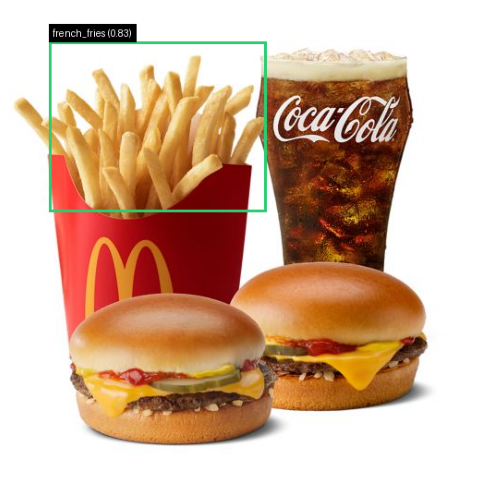

In [21]:
# --- Food classification with Img drawing ---

from PIL import ImageDraw, ImageFont
import matplotlib.pyplot as plt

def draw_annotated(image_path, results, outfile="annotated_food.jpg"):
    # load the same source image used for detection/classification
    if image_path.startswith('http'):
        resp = requests.get(image_path)
        img = Image.open(BytesIO(resp.content)).convert("RGB")
    else:
        img = Image.open(image_path).convert("RGB")

    draw = ImageDraw.Draw(img)

    # Try to get a font (fallback to default)
    try:
        font = ImageFont.load_default()
    except Exception:
        font = None

    for r in results:
        x1, y1, x2, y2 = r["bbox"]
        label = f"{r['food']} ({r['confidence']:.2f})"

        # box
        draw.rectangle([x1, y1, x2, y2], outline=(46, 204, 113), width=3)

        # label background box
        pad = 4
        tw, th = draw.textbbox((0, 0), label, font=font)[2:]
        bx1, by1 = x1, max(0, y1 - th - 2*pad)
        bx2, by2 = x1 + tw + 2*pad, y1
        draw.rectangle([bx1, by1, bx2, by2], fill=(0, 0, 0))
        draw.text((bx1 + pad, by1 + pad), label, fill=(255, 255, 255), font=font)

    img.save(outfile, quality=95)
    return outfile, img

# ---- RUN: analyze + draw ----
IMAGE_URL = "https://s7d1.scene7.com/is/image/mcdonalds/DC_202307_8950_EVM_M_2Cheeseburger_Coke_Glass_1564x1564-1:product-header-mobile?wid=500&hei=500&dpr=off"

results = analyze_food(IMAGE_URL, conf_threshold=0.3)

# pretty print to confirm
for idx, r in enumerate(results, 1):
    print(f"Detection {idx}: {r['food']}  conf={r['confidence']:.2f}  bbox={r['bbox']}")
    print(f"  top-3: {r['all_predictions']}")

# draw + show
outfile, annotated = draw_annotated(IMAGE_URL, results, outfile="annotated_food.jpg")
print(f"\nSaved annotated image -> {outfile}")

plt.figure(figsize=(6,6))
plt.imshow(annotated)
plt.axis("off")
plt.show()
